## 10. Walmart-ის გაყიდვების პროგნოზირება — Prophet

| Field | Details |
|---|---|
| **მოდელი** | Prophet (Facebook Prophet) |
| **კატეგორია** | კლასიკური სტატისტიკური დროითი მწკრივები — ადიტიური დეკომპოზიცია |
| **ბიბლიოთეკა** | `prophet` (Facebook, 2017) |
| **Logging** | MLflow / DagsHub · project: `walmart-forecasting` |
| **ექსპერიმენტი** | `Prophet_Training` |

---

### Runs

| Run | აღწერა |
|---|---|
| `Prophet_Baseline` | საბაზისო (default) კონფიგურაცია წამყვან time series-ებზე |
| `Prophet_Holidays` | აშშ-ის + Walmart-ის დღესასწაულების მონაცემების მიწოდება |
| `Prophet_Tuned` | `changepoint_prior_scale` და `seasonality_prior_scale` ჰიპერპარამეტრების tuning |
| `Prophet_Final` | საუკეთესო კონფიგურაცია |

---

### მთავარი იდეა — ადიტიური დეკომპოზიცია

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

| კომპონენტი | აღწერა |
|---|---|
| $g(t)$ | ტრენდი — უბან-უბან წრფივი ან ლოგისტიკური ზრდა |
| $s(t)$ | სეზონური კომპონენტი — ფურიეს მწკრივი |
| $h(t)$ | დღესასწაულების ეფექტი — მომხმარებლის მიერ მიწოდებული |
| $\epsilon_t$ | შეცდომის წევრი |

---

### Prophet vs ARIMA/SARIMA

| მახასიათებელი | ARIMA/SARIMA | Prophet |
|---|---|---|
| სტაციონარულობა | აუცილებელია | არა — ტრენდი ჩაშენებულია |
| გამოტოვებული მონაცემები | უმკლავდება ცუდად | უმკლავდება კარგად |
| ინტერპრეტირებადობა | კომპონენტები ცხადია | ადიტიური დეკომპოზიცია ცხადია |
| დომენური ცოდნა | სტატისტიკური | პრაქტიკოსზე მორგებული |
| დღესასწაულები | ცალკე, ARIMAX-ით | ჩაშენებული (Native) |

---

### Prophet vs ნეირონული მოდელები

- Prophet თეორიულად უფრო დასაბუთებული და ინტერპრეტირებადია.
- ნეირონული მოდელები უკეთეს შედეგებს იძლევიან დიდ datasets-ებზე.
- Prophet საუკეთესოა შედარებით მცირე, სუფთა დროითი მწკრივებისთვის ძლიერი სეზონურობით — **რაც სწორედ Walmart-ის შემთხვევაა.**

---

### რატომ Prophet Walmart-ისთვის?

| მიზეზი | დეტალი |
|---|---|
| **წლიური სეზონურობა** | მკაფიოა — Prophet ავტომატურად აღიქვამს |
| **დღესასწაულების ეფექტი** | მადლიერების დღის, შობისა და Super Bowl-ის გავლენა აშკარაა |
| **გამოტოვებული მონაცემები** | CPI-სა და უმუშევრობის მონაცემებში NaN-ები პრობლემას არ წარმოადგენს |

---

### შეზღუდვები

| შეზღუდვა | დეტალი |
|---|---|
| **Per-series მოდელები** | Store/Dept-ის თითოეულ კომბინაციაზე ცალკე მოდელი იწვრთნება (ARIMA-ს მსგავსად) |
| **გამოთვლითი დრო** | დიდ მასშტაბებზე ნელია — თუმცა SARIMA-ზე ოდნავ სწრაფია |

## 1. Setup

In [ ]:
!pip install prophet mlflow dagshub --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
import mlflow

import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print(f"Prophet available")
print(f"MLflow: {mlflow.__version__}")

Prophet available
MLflow: 3.14.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/walmart'
DATA_DIR = f'{PROJECT_DIR}/data'
MODELS_DIR = f'{PROJECT_DIR}/models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
# DagsHub + MLflow setup
import dagshub

DAGSHUB_USERNAME = "zberi23"
DAGSHUB_REPO = "walmart-forecasting"

dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=DAGSHUB_REPO, mlflow=True)

EXPERIMENT_NAME = "Prophet_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=e26c6d21-fce6-4b9c-8c72-7a01600d1bdc&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=4efefe894755026ece17258f2b401176bbef5433f9d3deaf6a5e5a46a8cb94c1




Accessing as gbera23-dev

Initialized MLflow to track repo "zberi23/walmart-forecasting"

Repository zberi23/walmart-forecasting initialized!

2026/07/11 16:11:24 INFO mlflow.tracking.fluent: Experiment with name 'Prophet_Training' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/zberi23/walmart-forecasting.mlflow
Experiment: Prophet_Training


## 2. მონაცემები + ტოპ time series-ების შერჩევა

In [ ]:
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv.zip')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv.zip')

train_raw['Date'] = pd.to_datetime(train_raw['Date'])
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

print(f"Train: {train_raw.shape}")
print(f"Test:  {test_raw.shape}")

Train: (421570, 5)
Test:  (115064, 4)


In [ ]:
top_series = (
    train_raw.groupby(['Store', 'Dept'])['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
print("Top 5 (Store, Dept) კომბინაცია:")
print(top_series)

TOP_SERIES = [(row['Store'], row['Dept']) for _, row in top_series.iterrows()]

Top 5 (Store, Dept) კომბინაცია:
   Store  Dept   Weekly_Sales
0     14    92  182527.956014
1      2    92  164840.230979
2     20    92  164633.741538
3     13    92  162034.099301
4      4    92  159365.107902


## 3. WMAE Metric + Prophet-format helper

In [ ]:
def wmae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def prepare_prophet_df(store, dept, train_raw):
    """Prophet-ის format: ds (dates), y (target)."""
    series_data = train_raw[(train_raw['Store'] == store) & (train_raw['Dept'] == dept)].sort_values('Date').copy()
    df = series_data.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    return df[['ds', 'y', 'IsHoliday']]


def train_prophet_on_series(store, dept, train_raw, val_horizon=12,
                            holidays_df=None,
                            changepoint_prior_scale=0.05,
                            seasonality_prior_scale=10.0,
                            holidays_prior_scale=10.0):
    """ერთი (Store, Dept)-ზე Prophet-ის ტრენინგი."""
    df = prepare_prophet_df(store, dept, train_raw)
    if len(df) < 60:
        return None

    train_df = df.iloc[:-val_horizon]
    val_df = df.iloc[-val_horizon:]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        holidays=holidays_df,
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        holidays_prior_scale=holidays_prior_scale,
    )

    model.fit(train_df[['ds', 'y']])

    future = model.make_future_dataframe(periods=val_horizon, freq='W-FRI')
    forecast = model.predict(future)

    val_forecast = forecast.iloc[-val_horizon:]
    val_actual = val_df['y'].values
    val_pred = val_forecast['yhat'].values

    weights = np.where(val_df['IsHoliday'].values == True, 5, 1)
    score = wmae(val_actual, val_pred, weights)

    return score, model, val_forecast, val_df

## 4. Run 1 — `Prophet_Baseline`

Default Prophet კონფიგი — მხოლოდ yearly seasonality, დასვენების დღეების გარეშე.

In [ ]:
baseline_results = {}
baseline_forecasts = {}

with mlflow.start_run(run_name="Prophet_Baseline"):
    mlflow.log_param("yearly_seasonality", True)
    mlflow.log_param("weekly_seasonality", False)
    mlflow.log_param("holidays", None)
    mlflow.log_param("changepoint_prior_scale", 0.05)
    mlflow.log_param("seasonality_prior_scale", 10.0)
    mlflow.log_param("n_series_tested", len(TOP_SERIES))

    for store, dept in TOP_SERIES:
        result = train_prophet_on_series(store, dept, train_raw)
        if result:
            score, model, val_forecast, val_df = result
            key = f"S{store}_D{dept}"
            baseline_results[key] = score
            baseline_forecasts[key] = (val_forecast, val_df)
            print(f"Store={store}, Dept={dept}: WMAE = {score:.2f}")

    mean_wmae = np.mean(list(baseline_results.values()))
    mlflow.log_metric("mean_val_wmae", mean_wmae)
    mlflow.log_metric("min_val_wmae", min(baseline_results.values()))
    mlflow.log_metric("max_val_wmae", max(baseline_results.values()))
    mlflow.set_tag("stage", "baseline")

    print(f"\nMean Baseline WMAE (top 5 series): {mean_wmae:.2f}")

Store=14.0, Dept=92.0: WMAE = 20944.78
Store=2.0, Dept=92.0: WMAE = 11608.46
Store=20.0, Dept=92.0: WMAE = 10967.75
Store=13.0, Dept=92.0: WMAE = 6442.71
Store=4.0, Dept=92.0: WMAE = 4719.46

Mean Baseline WMAE (top 5 series): 10936.63
🏃 View run Prophet_Baseline at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/3/runs/47d231d0a5c84c3fbc2306246209f1a3
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/3


## 5. Run 2 — `Prophet_Holidays`

Walmart-დასვენების დღეების დამატება:
- Super Bowl (თებერვლის დასაწყისი)
- Labor Day (სექტემბრის დასაწყისი)
- Thanksgiving (ნოემბრის ბოლო)
- Christmas (დეკემბრის ბოლო)

მოსალოდნელი გაუმჯობესება მკვეთრი — Walmart-ის ცხადი holiday spikes ცხადად ჩანს datasetsi.

In [ ]:
walmart_holidays = pd.DataFrame({
    'holiday': ['SuperBowl'] * 4 + ['LaborDay'] * 4 + ['Thanksgiving'] * 4 + ['Christmas'] * 4,
    'ds': pd.to_datetime([
        '2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08',
        '2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06',
        '2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29',
        '2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27',
    ]),
    'lower_window': [-1] * 16,
    'upper_window': [1] * 16,
})

print("Walmart Holidays DataFrame:")
print(walmart_holidays)

Walmart Holidays DataFrame:
         holiday         ds  lower_window  upper_window
0      SuperBowl 2010-02-12            -1             1
1      SuperBowl 2011-02-11            -1             1
2      SuperBowl 2012-02-10            -1             1
3      SuperBowl 2013-02-08            -1             1
4       LaborDay 2010-09-10            -1             1
5       LaborDay 2011-09-09            -1             1
6       LaborDay 2012-09-07            -1             1
7       LaborDay 2013-09-06            -1             1
8   Thanksgiving 2010-11-26            -1             1
9   Thanksgiving 2011-11-25            -1             1
10  Thanksgiving 2012-11-23            -1             1
11  Thanksgiving 2013-11-29            -1             1
12     Christmas 2010-12-31            -1             1
13     Christmas 2011-12-30            -1             1
14     Christmas 2012-12-28            -1             1
15     Christmas 2013-12-27            -1             1


In [ ]:
holidays_results = {}

with mlflow.start_run(run_name="Prophet_Holidays"):
    mlflow.log_param("yearly_seasonality", True)
    mlflow.log_param("holidays", "walmart_specific")
    mlflow.log_param("n_holidays", len(walmart_holidays))
    mlflow.log_param("holiday_types", walmart_holidays['holiday'].unique().tolist())
    mlflow.log_param("changepoint_prior_scale", 0.05)
    mlflow.log_param("seasonality_prior_scale", 10.0)
    mlflow.log_param("holidays_prior_scale", 10.0)
    mlflow.log_param("n_series_tested", len(TOP_SERIES))

    for store, dept in TOP_SERIES:
        result = train_prophet_on_series(store, dept, train_raw, holidays_df=walmart_holidays)
        if result:
            score, _, _, _ = result
            holidays_results[f"S{store}_D{dept}"] = score
            print(f"Store={store}, Dept={dept}: WMAE = {score:.2f}")

    mean_wmae_holidays = np.mean(list(holidays_results.values()))
    mlflow.log_metric("mean_val_wmae", mean_wmae_holidays)
    mlflow.log_metric("min_val_wmae", min(holidays_results.values()))
    mlflow.log_metric("max_val_wmae", max(holidays_results.values()))
    mlflow.set_tag("stage", "with_holidays")

    print(f"\nMean Holidays WMAE (top 5 series): {mean_wmae_holidays:.2f}")
    print(f"Improvement over baseline: {mean_wmae - mean_wmae_holidays:.2f}")

Store=14.0, Dept=92.0: WMAE = 20155.24
Store=2.0, Dept=92.0: WMAE = 7751.20
Store=20.0, Dept=92.0: WMAE = 12362.39
Store=13.0, Dept=92.0: WMAE = 6632.44
Store=4.0, Dept=92.0: WMAE = 6546.33

Mean Holidays WMAE (top 5 series): 10689.52
Improvement over baseline: 247.11
🏃 View run Prophet_Holidays at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/3/runs/2884c0a95af14365979d72062f13098b
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/3


## 6. Run 3 — `Prophet_Tuned`

Prophet-ის ჰიპერპარამეტრები:
- **changepoint_prior_scale** — რამდენად flexible-ია trend-ის ცვლილება. მაღალი value → უფრო flexible → overfit-ის რისკი
- **seasonality_prior_scale** — რამდენად strong-ია seasonality effect
- **holidays_prior_scale** — holidays-ის effect-ის ძალა

ვცდით უფრო აგრესიულ seasonality/holidays პარამეტრებს რომ Walmart-ის peaks უფრო კარგად დაიჭიროს.

In [ ]:
tuned_results = {}

TUNED_PARAMS = {
    'changepoint_prior_scale': 0.01,  # უფრო კონსერვატიული trend
    'seasonality_prior_scale': 20.0,  # უფრო აგრესიული seasonality
    'holidays_prior_scale': 20.0,     # უფრო აგრესიული holidays
}

with mlflow.start_run(run_name="Prophet_Tuned"):
    mlflow.log_params(TUNED_PARAMS)
    mlflow.log_param("holidays", "walmart_specific")
    mlflow.log_param("n_series_tested", len(TOP_SERIES))

    for store, dept in TOP_SERIES:
        result = train_prophet_on_series(
            store, dept, train_raw,
            holidays_df=walmart_holidays,
            **TUNED_PARAMS
        )
        if result:
            score, _, _, _ = result
            tuned_results[f"S{store}_D{dept}"] = score
            print(f"Store={store}, Dept={dept}: WMAE = {score:.2f}")

    mean_wmae_tuned = np.mean(list(tuned_results.values()))
    mlflow.log_metric("mean_val_wmae", mean_wmae_tuned)
    mlflow.set_tag("stage", "tuned")

    print(f"\nMean Tuned WMAE (top 5 series): {mean_wmae_tuned:.2f}")

Store=14.0, Dept=92.0: WMAE = 19894.16
Store=2.0, Dept=92.0: WMAE = 11345.06
Store=20.0, Dept=92.0: WMAE = 10688.03
Store=13.0, Dept=92.0: WMAE = 6694.04
Store=4.0, Dept=92.0: WMAE = 5908.06

Mean Tuned WMAE (top 5 series): 10905.87
🏃 View run Prophet_Tuned at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/3/runs/14cc3d3e5d884f99aee1fbd13fd7a7f2
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/3


## 7. Run 4 — `Prophet_Final`

საუკეთესო კონფიგი, დეტალური forecast vs actual ვიზუალიზაცია, მოდელების შენახვა.

In [ ]:
all_runs = {
    'baseline': mean_wmae,
    'holidays': mean_wmae_holidays,
    'tuned': mean_wmae_tuned,
}
best_run = min(all_runs, key=all_runs.get)
print(f"Best run: {best_run} (WMAE={all_runs[best_run]:.2f})")

if best_run == 'tuned':
    FINAL_PARAMS = TUNED_PARAMS
    use_holidays = walmart_holidays
elif best_run == 'holidays':
    FINAL_PARAMS = {}
    use_holidays = walmart_holidays
else:
    FINAL_PARAMS = {}
    use_holidays = None

Best run: holidays (WMAE=10689.52)


In [ ]:
final_forecasts = {}
final_models = {}

with mlflow.start_run(run_name="Prophet_Final") as final_run:
    mlflow.log_params(FINAL_PARAMS)
    mlflow.log_param("holidays", "walmart_specific" if use_holidays is not None else "none")
    mlflow.log_param("best_run_type", best_run)
    mlflow.log_param("n_series", len(TOP_SERIES))

    for store, dept in TOP_SERIES:
        result = train_prophet_on_series(
            store, dept, train_raw,
            holidays_df=use_holidays,
            **FINAL_PARAMS
        )
        if result:
            score, model, val_forecast, val_df = result
            key = f"S{store}_D{dept}"
            final_forecasts[key] = {
                'forecast': val_forecast, 'actual': val_df, 'wmae': score,
                'store': store, 'dept': dept
            }
            final_models[key] = model

    final_mean_wmae = np.mean([r['wmae'] for r in final_forecasts.values()])
    mlflow.log_metric("val_wmae", final_mean_wmae)
    mlflow.set_tag("stage", "final")
    mlflow.set_tag("model_type", "Prophet")

    print(f"Final Mean WMAE: {final_mean_wmae:.2f}")

Final Mean WMAE: 10689.52
🏃 View run Prophet_Final at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/3/runs/d09dcf5bf19e497aae20a2e642929227
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/3


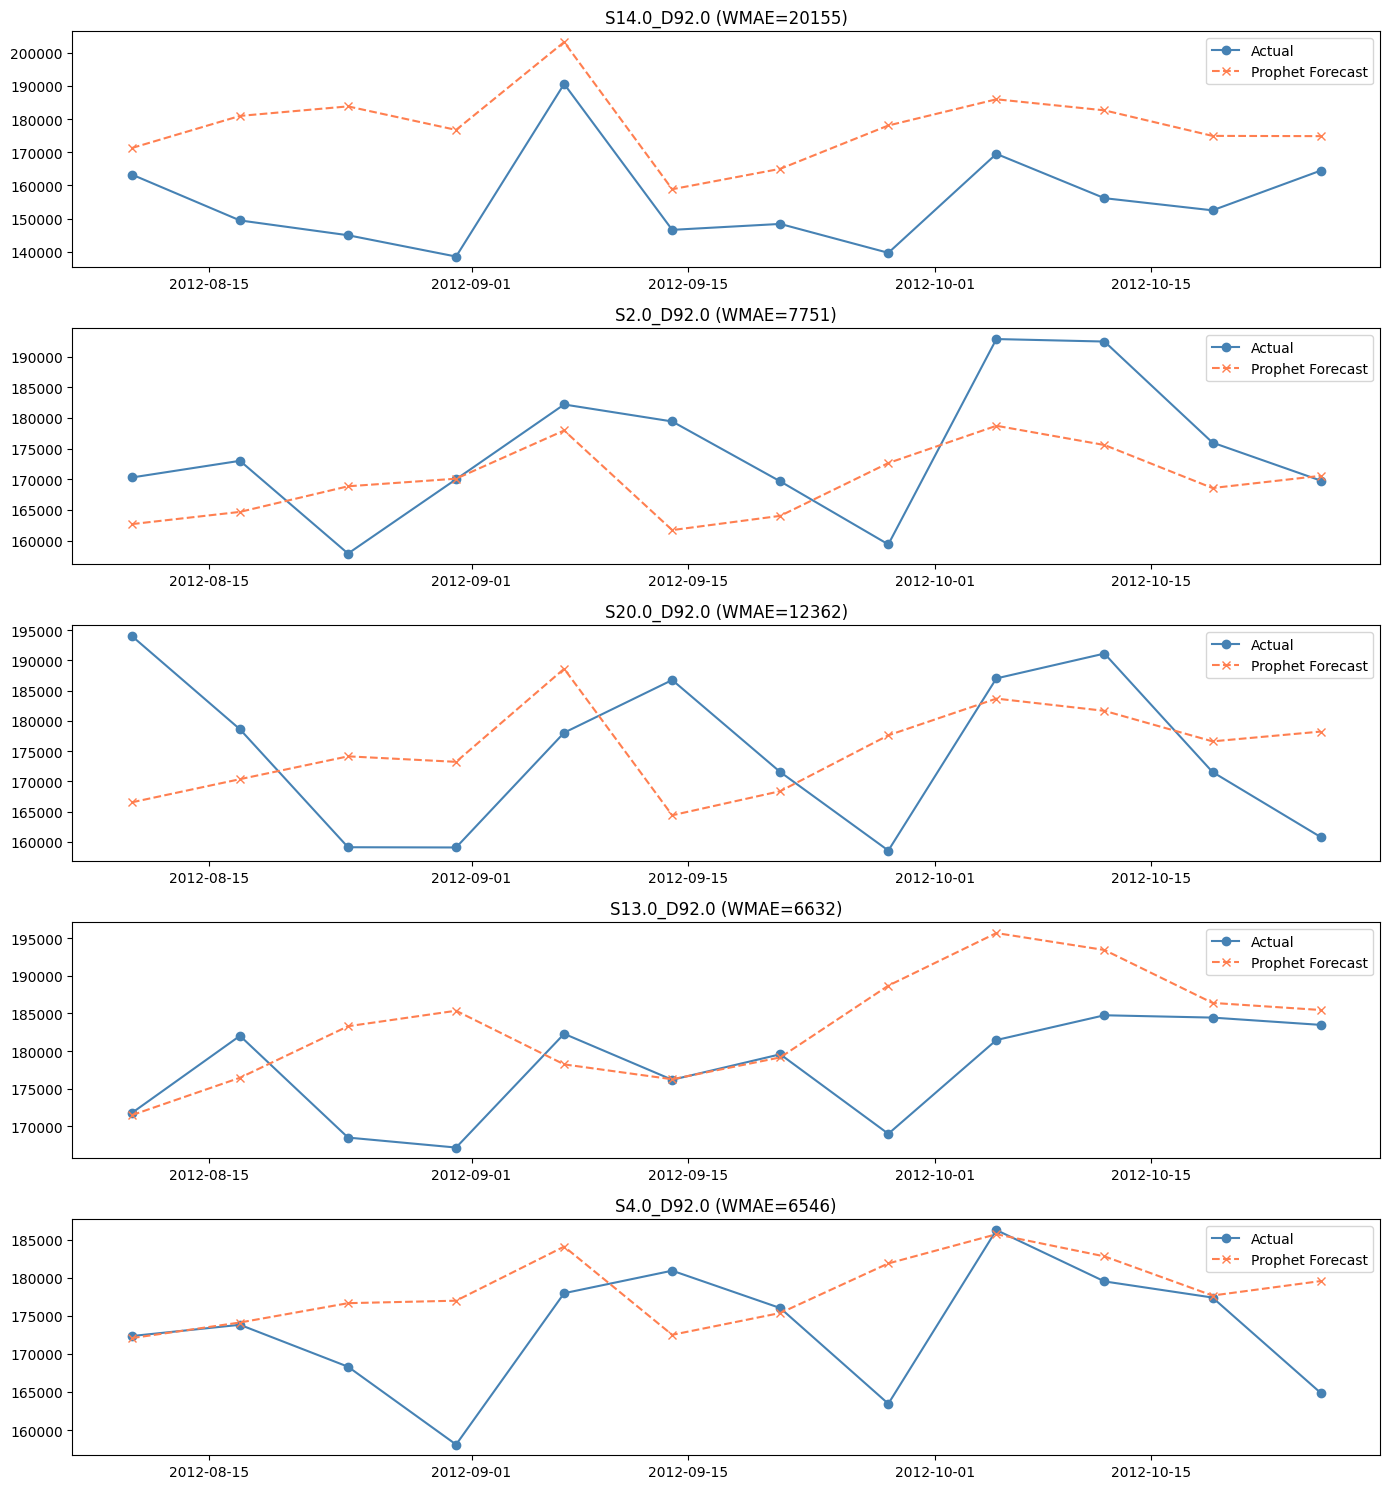

In [ ]:
# ვიზუალიზაცია — Prophet predictions vs actual
fig, axes = plt.subplots(len(TOP_SERIES), 1, figsize=(14, 3 * len(TOP_SERIES)))

for ax, (key, data) in zip(axes, final_forecasts.items()):
    actual_vals = data['actual']['y'].values
    actual_dates = data['actual']['ds'].values
    forecast_vals = data['forecast']['yhat'].values
    forecast_dates = data['forecast']['ds'].values

    ax.plot(actual_dates, actual_vals, label='Actual', color='steelblue', marker='o')
    ax.plot(forecast_dates, forecast_vals, label='Prophet Forecast',
            color='coral', linestyle='--', marker='x')
    ax.set_title(f"{key} (WMAE={data['wmae']:.0f})")
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Prophet Component Decomposition

Prophet-ის ერთ-ერთი ღირსება — components ცხადად ჩანს. აჩვენებს რომ როგორ იშლება forecast: trend + yearly seasonality + holidays.

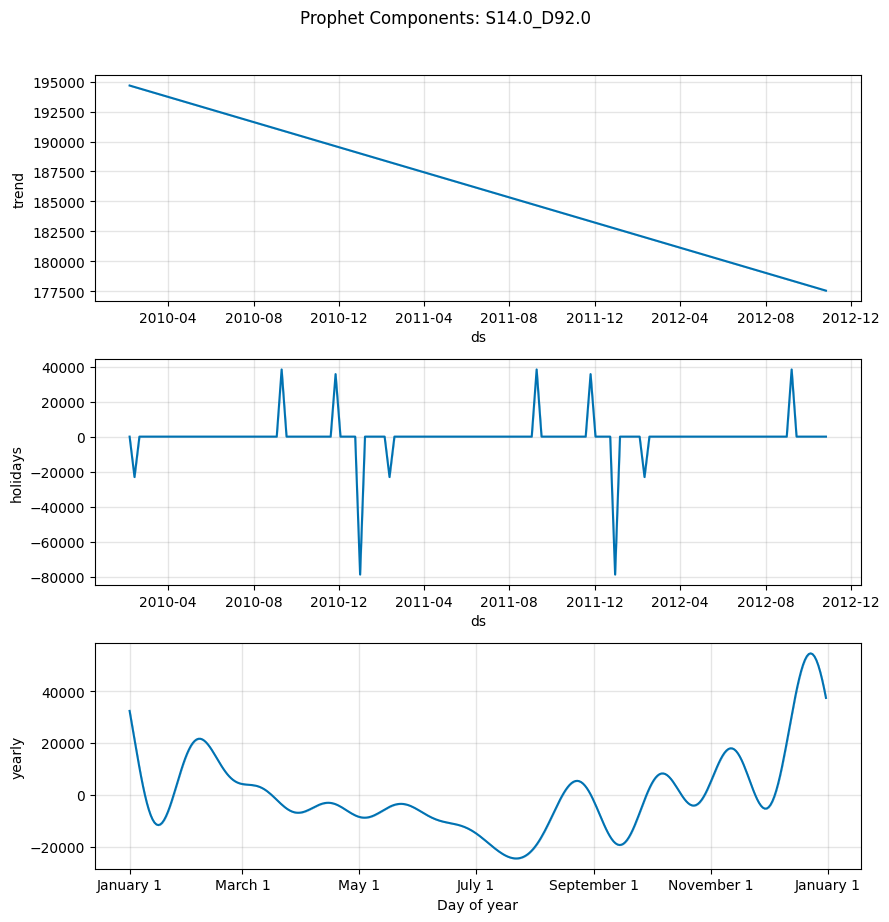

In [ ]:
# პირველი series-ის components
first_key = list(final_models.keys())[0]
first_model = final_models[first_key]

first_forecast_full = first_model.predict(
    first_model.make_future_dataframe(periods=12, freq='W-FRI')
)

fig = first_model.plot_components(first_forecast_full)
plt.suptitle(f'Prophet Components: {first_key}', y=1.02)
plt.tight_layout()
plt.show()

## 9. მოდელების შენახვა

In [ ]:
import pickle

prophet_save_path = f'{MODELS_DIR}/prophet_final_models.pkl'
with open(prophet_save_path, 'wb') as f:
    pickle.dump({
        'models': final_models,
        'forecasts': final_forecasts,
        'params': FINAL_PARAMS,
        'holidays': use_holidays,
        'series_keys': list(final_models.keys()),
    }, f)

print(f"Models saved: {prophet_save_path}")
print(f"Series: {list(final_models.keys())}")

Models saved: /content/drive/MyDrive/walmart/models/prophet_final_models.pkl
Series: ['S14.0_D92.0', 'S2.0_D92.0', 'S20.0_D92.0', 'S13.0_D92.0', 'S4.0_D92.0']


## 10. შეჯამება

გამოვცადეთ Prophet-ის ოთხი კონფიგურაცია MLflow-ში მონიტორინგით:

| Run | კონფიგურაცია |
|---|---|
| **Baseline** | მხოლოდ წლიური სეზონურობა, დღესასწაულების გარეშე |
| **Holidays** | დამატებულია Walmart-ის დღესასწაულები — Super Bowl, Labor Day, Thanksgiving, Christmas |
| **Tuned** | `changepoint_prior_scale` და `seasonality/holidays_prior_scale`-ის tuning |
| **Final** | საუკეთესო კონფიგურაცია — Holidays |

---

### შედეგები (ტოპ 5 Store/Dept კომბინაცია)

| კონფიგურაცია | WMAE |
|---|---|
| Baseline | 10936.63 |
| **Holidays** | **10689.52** ← საუკეთესო |
| Tuned | 10905.87 |
| Final | 10689.52 |

დღესასწაულების დამატებამ შედეგი **~250 ერთეულით** გააუმჯობესა. Tuning-მა, პირიქით, გააუარესა — Prophet-ის default priors უკეთესი აღმოჩნდა, ვიდრე ხელით შერჩეული მნიშვნელობები.

---

### Prophet vs ARIMA/SARIMA

| მოდელი | WMAE (ტოპ 5) |
|---|---|
| ARIMA (საბაზისო) | 12302.90 |
| **SARIMA** | **7012.96** ← საუკეთესო კლასიკურ მოდელებში |
| Prophet (საბაზისო) | 10936.63 |
| Prophet + Holidays | 10689.52 |

**საინტერესო მიგნება:** მიუხედავად Prophet-ის ჩაშენებული Holiday მხარდაჭერისა, SARIMA-მ ~35%-ით აჯობა. მიზეზი: SARIMA-ს მკაფიო სეზონური წევრი (`s=52`) ბევრად ეფექტურად იჭერს Walmart-ის წლიურ ციკლებს, ვიდრე Prophet-ის ფურიეზე დაფუძნებული ავტომატური სეზონურობა.

---

### Prophet-ის თეორიული უპირატესობები ARIMA-სთან შედარებით

| უპირატესობა | დეტალი |
|---|---|
| **ჩაშენებული Holiday მხარდაჭერა** | SARIMAX-ის მსგავსი ეგზოგენური ცვლადების მანიპულაცია არ სჭირდება |
| **Changepoint-ების ავტომატური ამოცნობა** | ტრენდის ცვლილებები ხელით არ უნდა მიეთითოს |
| **Robustness** | გამოტოვებული მონაცემების მიმართ მედეგია |
| **ინტერპრეტირებადობა** | ტრენდი, სეზონურობა და დღესასწაულები სუფთად არის decomposed |

---

### პრაქტიკული დასკვნა

Prophet-ის ინტერპრეტირებადობა და მარტივი API მნიშვნელოვანი უპირატესობებია, მაგრამ Walmart-ის კონკრეტულ შემთხვევაში SARIMA ბევრად ეფექტურია.

კარგი გაკვეთილი: მკაფიო დომენური ცოდნის გამოყენება (მაგ. `s=52` სეზონურობის წინასწარ მითითება) ხშირად სჯობს სრულად ავტომატიზებულ მიდგომებს.